# Livelock in Python

## Outline

- a clear explanation of livelock
- the difference between deadlock, livelock, and starvation
- a minimal livelock example in Python
- a full Dining Philosophers simulation
- a **livelock-prone "polite philosopher" strategy**
- a deadlock-free and livelock-free corrected strategy
- comparison tables and plots

---

## What you should expect to learn from this notebook

By the end of this notebook, you should be able to:

1. Define **livelock**
2. Distinguish livelock from deadlock and starvation
3. Explain how a system may remain active but fail to make useful progress
4. Understand why Dining Philosophers can model both deadlock and livelock
5. Implement a strategy that avoids livelock by improving coordination

In [1]:
import threading
import time
import random
from dataclasses import dataclass, asdict

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

random.seed(42)

## 1. What is livelock?

A **livelock** is a concurrency problem in which threads/processes are **not blocked**, but they keep reacting to each other in a way that prevents useful progress.

### Intuition

In a **deadlock**:
- participants are waiting forever

In a **livelock**: 
- participants are active
- they keep changing state
- but nobody finishes the intended work

A simple human analogy is two polite people in a hallway:
- both move left
- both move right
- both keep adjusting
- neither gets through

They are active, but progress is missing.

## 2. Deadlock vs livelock vs starvation

### Deadlock
Participants are blocked forever waiting on each other.

### Livelock
Participants are active and responsive, but repeated reactions prevent completion.

### Starvation
Some participant could proceed in principle, but keeps being denied progress because others repeatedly get access first.

### Summary:

- **Deadlock** = waiting forever
- **Livelock** = moving forever without finishing
- **Starvation** = someone is repeatedly left behind

## 3. Minimal livelock example

We begin with a tiny example using two workers and two locks.

### Strategy
- Worker A tries to get `lock_1`, then `lock_2`
- Worker B tries to get `lock_2`, then `lock_1`
- If the second lock is unavailable, each worker politely releases the first lock and retries

This is cooperative behavior, but it can create a livelock pattern:
- both workers stay active
- both keep retrying
- useful progress can be delayed or prevented

In [2]:
def minimal_livelock_demo(max_attempts=20, pause=0.01):
    """
    Demonstrate a livelock-like pattern with two workers and two locks.

    The workers are cooperative:
    if they fail to get the second lock, they release the first one and retry.
    This means the system is active, but useful progress may be limited.

    Returns
    -------
    dict
        Summary including whether useful work was completed and an event log.
    """
    lock_1 = threading.Lock()
    lock_2 = threading.Lock()
    events = []
    progress = {"A": 0, "B": 0}

    barrier = threading.Barrier(2)

    def worker(name, first, second):
        barrier.wait()

        for attempt in range(1, max_attempts + 1):
            events.append(f"{name}: attempt {attempt} acquiring first lock")
            got_first = first.acquire(timeout=0.05)

            if not got_first:
                events.append(f"{name}: could not get first lock, retrying")
                time.sleep(pause)
                continue

            events.append(f"{name}: acquired first lock, trying second lock")
            got_second = second.acquire(blocking=False)

            if got_second:
                try:
                    events.append(f"{name}: acquired both locks -> useful progress")
                    progress[name] += 1
                    time.sleep(0.02)
                    return
                finally:
                    second.release()
                    first.release()
                    events.append(f"{name}: released both locks")
            else:
                events.append(f"{name}: second lock unavailable -> releasing first lock and retrying")
                first.release()
                time.sleep(pause)

        events.append(f"{name}: exhausted attempts")

    t1 = threading.Thread(target=worker, args=("A", lock_1, lock_2))
    t2 = threading.Thread(target=worker, args=("B", lock_2, lock_1))

    start = time.perf_counter()
    t1.start()
    t2.start()
    t1.join()
    t2.join()
    elapsed = time.perf_counter() - start

    return {
        "elapsed_s": elapsed,
        "progress_A": progress["A"],
        "progress_B": progress["B"],
        "total_progress": progress["A"] + progress["B"],
        "livelock_symptom_detected": (progress["A"] + progress["B"] < 2),
        "events": events,
    }

minimal_result = minimal_livelock_demo()
minimal_result

{'elapsed_s': 0.04113090800092323,
 'progress_A': 1,
 'progress_B': 1,
 'total_progress': 2,
 'livelock_symptom_detected': False,
 'events': ['B: attempt 1 acquiring first lock',
  'B: acquired first lock, trying second lock',
  'B: acquired both locks -> useful progress',
  'A: attempt 1 acquiring first lock',
  'B: released both locks',
  'A: acquired first lock, trying second lock',
  'A: acquired both locks -> useful progress',
  'A: released both locks']}

### Interpretation

The workers do not freeze. They continue to:

- acquire
- release
- retry
- react to each other

That is exactly why livelock is tricky:

> the system looks busy, but useful work may be very low.

In real systems, randomized backoff or an ordering rule is often used to break this pattern.

## 4. Dining Philosophers and livelock

### Reminder of the problem
- Five philosophers sit around a circular table
- A fork lies between each pair
- A philosopher needs **both adjacent forks** to eat
- Otherwise, the philosopher must keep waiting or retrying

### Why it is a great livelock example?
The same setup can demonstrate different failures depending on behavior:

- **Deadlock**: everyone picks up one fork and waits forever
- **Livelock**: everyone politely picks up one fork, fails to get the other, puts the first back, and retries
- **Correct behavior**: a coordination rule ensures progress


In [4]:
@dataclass
class PhilosopherRunSummary:
    strategy: str
    n_philosophers: int
    rounds_per_philosopher: int
    completed: bool
    total_meals: int
    avg_meals_per_philosopher: float
    min_meals_by_any_philosopher: int
    max_meals_by_any_philosopher: int
    total_retries: int
    avg_retries_per_philosopher: float
    elapsed_s: float

def philosopher_names(n):
    return [f"P{i}" for i in range(n)]

## 5. Livelock-prone Dining Philosophers strategy

Now we intentionally implement a **polite philosopher** strategy.

### Behavior
Each philosopher:
1. thinks for a while
2. picks up the left fork
3. tries to pick up the right fork
4. if the right fork is unavailable:
   - puts down the left fork
   - waits briefly
   - retries later

This is cooperative, but if all philosophers behave this way at nearly the same time, they may keep interfering with each other indefinitely.

That is livelock-like behavior:
- everyone is active
- forks are repeatedly picked up and released
- meals may be delayed or reduced

In [5]:
def run_dining_philosophers_livelock(
    n=5,
    rounds=6,
    think_time=0.02,
    eat_time=0.03,
    retry_pause=0.01,
    max_attempts_per_round=20,
):
    """
    Livelock-prone Dining Philosophers simulation.

    Philosophers are 'polite':
    - pick up left fork
    - if right fork is unavailable, release left fork and retry later

    This avoids permanent blocking, but can create active non-progress behavior.

    Returns
    -------
    summary, events, meals, retries
    """
    forks = [threading.Lock() for _ in range(n)]
    names = philosopher_names(n)
    meals = {name: 0 for name in names}
    retries = {name: 0 for name in names}
    events = []

    start_barrier = threading.Barrier(n)

    def philosopher(i):
        left = forks[i]
        right = forks[(i + 1) % n]
        name = names[i]

        start_barrier.wait()

        for r in range(rounds):
            events.append(f"{name}: thinking (round {r+1})")
            time.sleep(think_time)

            success = False

            for attempt in range(1, max_attempts_per_round + 1):
                retries[name] += 1
                events.append(f"{name}: round {r+1}, attempt {attempt}, trying LEFT fork")

                got_left = left.acquire(timeout=0.02)
                if not got_left:
                    events.append(f"{name}: could not acquire LEFT fork")
                    time.sleep(retry_pause)
                    continue

                events.append(f"{name}: acquired LEFT fork, trying RIGHT fork")
                got_right = right.acquire(blocking=False)

                if got_right:
                    try:
                        events.append(f"{name}: acquired RIGHT fork -> eating")
                        time.sleep(eat_time)
                        meals[name] += 1
                        success = True
                        break
                    finally:
                        right.release()
                        left.release()
                        events.append(f"{name}: released both forks")
                else:
                    events.append(f"{name}: RIGHT fork unavailable -> releasing LEFT fork and retrying")
                    left.release()
                    time.sleep(retry_pause)

            if not success:
                events.append(f"{name}: failed to eat in round {r+1}")

    threads = [threading.Thread(target=philosopher, args=(i,)) for i in range(n)]

    start = time.perf_counter()
    for t in threads:
        t.start()
    for t in threads:
        t.join()
    elapsed = time.perf_counter() - start

    total_meals = sum(meals.values())
    total_retries = sum(retries.values())

    summary = PhilosopherRunSummary(
        strategy="Livelock-prone: polite release-and-retry",
        n_philosophers=n,
        rounds_per_philosopher=rounds,
        completed=(total_meals == n * rounds),
        total_meals=total_meals,
        avg_meals_per_philosopher=total_meals / n,
        min_meals_by_any_philosopher=min(meals.values()),
        max_meals_by_any_philosopher=max(meals.values()),
        total_retries=total_retries,
        avg_retries_per_philosopher=total_retries / n,
        elapsed_s=elapsed,
    )

    return summary, events, meals, retries

livelock_summary, livelock_events, livelock_meals, livelock_retries = run_dining_philosophers_livelock()
pd.DataFrame([asdict(livelock_summary)])

,strategy,n_philosophers,rounds_per_philosopher,completed,total_meals,avg_meals_per_philosopher,min_meals_by_any_philosopher,max_meals_by_any_philosopher,total_retries,avg_retries_per_philosopher,elapsed_s
0,Livelock-prone: polite release-and-retry,5,6,False,29,5.8,5,6,60,12.0,0.594871


In [6]:
pd.DataFrame({
    "philosopher": list(livelock_meals.keys()),
    "meals_completed": list(livelock_meals.values()),
    "retry_attempts": [livelock_retries[p] for p in livelock_meals.keys()],
})

,philosopher,meals_completed,retry_attempts
0,P0,6,7
1,P1,6,10
2,P2,5,25
3,P3,6,12
4,P4,6,6


### Interpretation

This version is not blocked in the deadlock sense.

Instead:
- philosophers keep trying
- forks keep changing hands
- retries accumulate
- some rounds may fail to complete

This is the key symptom of livelock:
**active coordination without enough useful progress**.

## 6. Correct strategy: break symmetry and reduce interference

Each philosopher always acquires the **lower-indexed fork first**, then the higher-indexed fork.

This gives a global resource ordering and improves progress.

Although lock ordering is often introduced to prevent deadlock, it also helps here because it reduces the pathological symmetry that causes repeated mutual interference.

In [7]:
def run_dining_philosophers_ordered(
    n=5,
    rounds=6,
    think_time=0.02,
    eat_time=0.03,
):
    """
    Dining Philosophers with global fork ordering.

    This removes circular symmetry by ensuring every philosopher acquires
    forks according to a global rule.

    Returns
    -------
    summary, events, meals
    """
    forks = [threading.Lock() for _ in range(n)]
    names = philosopher_names(n)
    meals = {name: 0 for name in names}
    events = []

    def philosopher(i):
        left_idx = i
        right_idx = (i + 1) % n
        first_idx, second_idx = sorted([left_idx, right_idx])

        first = forks[first_idx]
        second = forks[second_idx]
        name = names[i]

        for r in range(rounds):
            events.append(f"{name}: thinking (round {r+1})")
            time.sleep(think_time)

            events.append(f"{name}: trying fork {first_idx}")
            with first:
                events.append(f"{name}: acquired fork {first_idx}")
                time.sleep(0.005)

                events.append(f"{name}: trying fork {second_idx}")
                with second:
                    events.append(f"{name}: acquired fork {second_idx} -> eating")
                    time.sleep(eat_time)
                    meals[name] += 1

                events.append(f"{name}: released fork {second_idx}")
            events.append(f"{name}: released fork {first_idx}")

    threads = [threading.Thread(target=philosopher, args=(i,)) for i in range(n)]

    start = time.perf_counter()
    for t in threads:
        t.start()
    for t in threads:
        t.join()
    elapsed = time.perf_counter() - start

    total_meals = sum(meals.values())

    summary = PhilosopherRunSummary(
        strategy="Correct: global fork ordering",
        n_philosophers=n,
        rounds_per_philosopher=rounds,
        completed=(total_meals == n * rounds),
        total_meals=total_meals,
        avg_meals_per_philosopher=total_meals / n,
        min_meals_by_any_philosopher=min(meals.values()),
        max_meals_by_any_philosopher=max(meals.values()),
        total_retries=0,
        avg_retries_per_philosopher=0.0,
        elapsed_s=elapsed,
    )

    return summary, events, meals

ordered_summary, ordered_events, ordered_meals = run_dining_philosophers_ordered()
pd.DataFrame([asdict(ordered_summary)])

,strategy,n_philosophers,rounds_per_philosopher,completed,total_meals,avg_meals_per_philosopher,min_meals_by_any_philosopher,max_meals_by_any_philosopher,total_retries,avg_retries_per_philosopher,elapsed_s
0,Correct: global fork ordering,5,6,True,30,6.0,6,6,0,0.0,0.565303


In [8]:
pd.DataFrame({
    "philosopher": list(ordered_meals.keys()),
    "meals_completed": list(ordered_meals.values()),
})

,philosopher,meals_completed
0,P0,6
1,P1,6
2,P2,6
3,P3,6
4,P4,6


## 7. Compare the two strategies

1. **Livelock-prone polite strategy**
2. **Correct ordered strategy**

In [9]:
comparison = pd.DataFrame([
    asdict(livelock_summary),
    asdict(ordered_summary),
])
comparison

,strategy,n_philosophers,rounds_per_philosopher,completed,total_meals,avg_meals_per_philosopher,min_meals_by_any_philosopher,max_meals_by_any_philosopher,total_retries,avg_retries_per_philosopher,elapsed_s
0,Livelock-prone: polite release-and-retry,5,6,False,29,5.8,5,6,60,12.0,0.594871
1,Correct: global fork ordering,5,6,True,30,6.0,6,6,0,0.0,0.565303


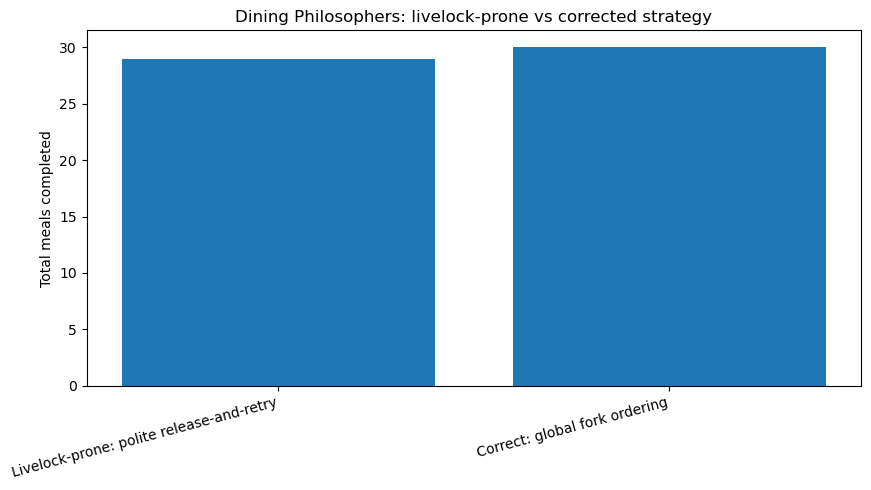

In [10]:
plt.figure(figsize=(9, 5))
plt.bar(comparison["strategy"], comparison["total_meals"])
plt.ylabel("Total meals completed")
plt.title("Dining Philosophers: livelock-prone vs corrected strategy")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

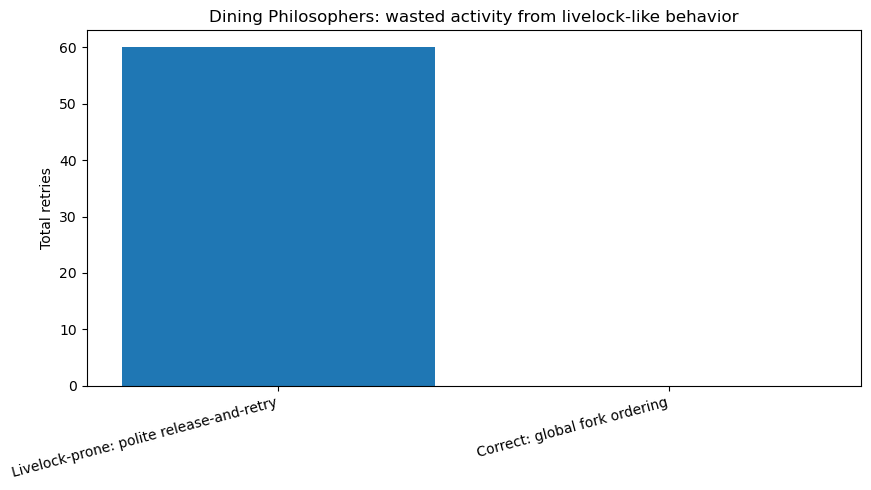

In [11]:
plt.figure(figsize=(9, 5))
plt.bar(comparison["strategy"], comparison["total_retries"])
plt.ylabel("Total retries")
plt.title("Dining Philosophers: wasted activity from livelock-like behavior")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

### Discussion

The livelock-prone version usually shows:

- more retry activity
- less predictable progress
- possible missed eating rounds

The ordered version usually shows:

- stable progress
- no unnecessary retries
- better completion reliability

### The Key Takeaway 

> Being more "active" does not always mean being more productive.

## 8. Why livelock happens here

Livelock in this example is caused by **symmetry + overreaction**.

All philosophers behave similarly:
- pick up one fork
- fail to get the other
- immediately release
- retry again

That creates a repeating interference pattern.

Ways to reduce livelock include:

- random backoff
- asymmetry in behavior
- global resource ordering
- centralized arbitration
- limiting how many actors compete at once

## 9. Real-world analogies

Livelock-like behavior appears in many real systems:

### Databases
Transactions repeatedly abort and retry after conflicts.

### Distributed systems
Multiple workers repeatedly try and release distributed locks.

### Networking
Endpoints repeatedly defer/retransmit in poorly tuned contention control.

### Cloud control loops
Controllers react too aggressively and oscillate.

### Human systems
Teams repeatedly negotiate and adjust without executing the plan.

The pattern is always similar:

- there is activity
- there is coordination
- but useful progress remains low

## 10. Key takeaways

1. **Livelock** means the system is active but not making enough useful progress.
2. It differs from deadlock because participants are not blocked.
3. Dining Philosophers is an excellent model for livelock because the same setup can show:
   - deadlock
   - livelock
   - correct coordination
4. A polite release-and-retry strategy can create livelock-like behavior.
5. A coordination rule such as **global ordering** improves progress and stability.

---

## 11. Suggested exercises

Try extending this notebook in the following ways:

- add randomized backoff to the livelock strategy
- compare fixed retry pause vs random retry pause
- add a semaphore allowing only `N - 1` philosophers to compete
- measure per-philosopher waiting time
- simulate starvation separately
- compare fairness between strategies